<h3 style="font-family: 'Times New Roman'; color:red;"><b>1. Import Libraries</b></h3>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec
import joblib
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#fafaf8','axes.facecolor':'#fafaf8',
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.4,'font.family':'DejaVu Sans',
})
ACCENT = '#c84b1e'
BLUE   = '#1a5fa8'
GREEN  = '#1a6b3f'
AMBER  = '#d68910'


<h3 style="font-family: 'Times New Roman'; color:red;"><b>2. Load Clean Data</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Load the output of Cleaning notebook. Confirm shape, column list, and
that no further rows were lost. All 46,667 records must be present.
</b></i></p>
<hr>

In [3]:
df=pd.read_csv('data/preprocessed/all_listings_with_flags.csv',parse_dates=['date_added'])
print(f'shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
# Ensure date column is datetime
print(f"Date range: {df['date_added'].min().date()} → {df['date_added'].max().date()}")


shape: (46667, 25)
Columns: ['property_id', 'page_url', 'property_type', 'price', 'location', 'latitude', 'longitude', 'baths', 'area', 'bedrooms', 'date_added', 'area_sqft', 'relisting_count', 'unique_url_count', 'relisting_span_days', 'ghost_listing_flag', 'year_week', 'listings_per_week_in_area', 'lat_anomaly', 'lon_anomaly', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag', 'suspicious_flag_count', 'is_suspicious']
Date range: 2018-08-07 → 2019-07-18


<h3 style="font-family: 'Times New Roman'; color:red;"><b>3. Train-Test Split</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Split the data 80/20 (stratified by is_suspicious) into train and test sets. Unsupervised models don't need labels for training, but the test set is used to evaluate the heuristic label later.</b></i></p>
<hr>    

In [4]:
# Heuristic fraud label (no ground truth available)
flag_cols = [
    'ghost_listing_flag',
    'lat_anomaly',
    'lon_anomaly',
    'geo_anomaly',
    'price_too_low_flag',
    'price_very_high_flag'
]

flag_cols = [c for c in flag_cols if c in df.columns]
print(f"Flag columns found: {flag_cols}")

print(f"\nLabel distribution:\n{df['is_suspicious'].value_counts()}")
print(f"Suspicious rate: {df['is_suspicious'].mean():.2%}")

Flag columns found: ['ghost_listing_flag', 'lat_anomaly', 'lon_anomaly', 'geo_anomaly', 'price_too_low_flag', 'price_very_high_flag']

Label distribution:
is_suspicious
0    42204
1     4463
Name: count, dtype: int64
Suspicious rate: 9.56%


In [5]:
# Raw split (no features computed yet)
random_state = 42

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=random_state,
    stratify=df['is_suspicious']
)

train_df = df.loc[train_idx].copy()
test_df  = df.loc[test_idx].copy()
print(f"\nTrain size : {len(train_df):,}  ({len(train_df)/len(df):.0%})")
print(f"Test  size : {len(test_df):,}  ({len(test_df)/len(df):.0%})")
print(f"Train suspicious: {train_df['is_suspicious'].mean():.2%}")
print(f"Test  suspicious: {test_df['is_suspicious'].mean():.2%}")



Train size : 37,333  (80%)
Test  size : 9,334  (20%)
Train suspicious: 9.56%
Test  suspicious: 9.57%


<h3 style="font-family: 'Times New Roman'; color:red;"><b>4. Temporal Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Extract time-based patterns, like day of week, month, and weekly listing volume, that can reveal coordinated ghost posting or market manipulation.</b></i></p>
<hr>    

In [6]:
def add_temporal_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add day-of-week, month, week-of-year, quarter, and is_weekend flags."""
    d = frame.copy()
    d['listing_month'] = d['date_added'].dt.month
    d['listing_quarter'] = d['date_added'].dt.quarter
    d['listing_dow'] = d['date_added'].dt.dayofweek        # 0=Mon … 6=Sun
    d['listing_week'] = d['date_added'].dt.isocalendar().week.astype(int)
    d['is_weekend']  = (d['listing_dow'] >= 5).astype(int)
    d['year_week']       = d['date_added'].dt.to_period('W').astype(str)
    return d

In [7]:
train_df = add_temporal_features(train_df)
test_df  = add_temporal_features(test_df)

print("Temporal features added:")
print(train_df[['listing_month','listing_quarter','listing_dow','listing_week','is_weekend']].head(3))


Temporal features added:
       listing_month  listing_quarter  listing_dow  listing_week  is_weekend
14069              6                2            4            23           0
44311              7                3            0            29           0
15883              4                2            1            15           0


<h3 style="font-family: 'Times New Roman'; color:red;"><b>5. Location Group Statistics</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Compute location-level price statistics from the train set, then measure each listing's price and price-per-sqft as an IQR-based deviation from its location's typical value. This is more robust to skewed data than a z-score.</b></i></p>
<hr>

In [8]:
#Compute location summary stats from TRAIN only
def compute_location_stats(frame: pd.DataFrame, price_col: str = 'price',
                            loc_col: str = 'location') -> pd.DataFrame:
    """
    Returns a DataFrame indexed by location with columns:
    mean, std, median, q25, q75, iqr
    Source: PBS Household Income Survey 2019 methodology for area stratification.
    """
    stats = frame.groupby(loc_col)[price_col].agg(
        loc_mean   = 'mean',
        loc_std    = 'std',
        loc_median = 'median',
        loc_q25    = lambda x: x.quantile(0.25),
        loc_q75    = lambda x: x.quantile(0.75),
    )
    stats['loc_iqr'] = stats['loc_q75'] - stats['loc_q25']
    return stats

In [9]:
loc_stats = compute_location_stats(train_df, price_col='price', loc_col='location')
print(f"Location stats computed for {len(loc_stats)} localities (train only)")
print(loc_stats.head(5))


Location stats computed for 192 localities (train only)
                                                loc_mean       loc_std  \
location                                                                 
APP Employees Co-operative Housing Society  3.900000e+07           NaN   
ASF Housing Scheme                          4.664000e+06  2.066200e+06   
ASF Tower                                   5.909091e+06  1.602158e+06   
Abdullah Ahmed Road                         6.645000e+07  8.987327e+07   
Abdullah Haroon Road                        2.066667e+07  1.860824e+07   

                                            loc_median     loc_q25  \
location                                                             
APP Employees Co-operative Housing Society  39000000.0  39000000.0   
ASF Housing Scheme                           4428000.0   2992000.0   
ASF Tower                                    5500000.0   5150000.0   
Abdullah Ahmed Road                         66450000.0  34675000.0   
Abdul

In [10]:
#Apply group stats to BOTH train and test
def apply_group_features(frame: pd.DataFrame, stats: pd.DataFrame, price_col: str = 'price', loc_col: str = 'location') -> pd.DataFrame:
    """
    Compute z-score and IQR deviation using pre-fitted group statistics.
    For test rows whose location is absent in stats, fallback to global train median/IQR.
    """
    d = frame.copy()

    global_mean   = stats['loc_mean'].mean()
    global_std    = stats['loc_std'].mean()
    global_median = stats['loc_median'].mean()
    global_iqr    = stats['loc_iqr'].mean()

    d['_loc_mean']   = d[loc_col].map(stats['loc_mean']).fillna(global_mean)
    d['_loc_std']    = d[loc_col].map(stats['loc_std']).fillna(global_std).replace(0, global_std)
    d['_loc_median'] = d[loc_col].map(stats['loc_median']).fillna(global_median)
    d['_loc_iqr']    = d[loc_col].map(stats['loc_iqr']).fillna(global_iqr).replace(0, global_iqr)
    d['_loc_q25']    = d[loc_col].map(stats['loc_q25']).fillna(global_median - global_iqr / 2)

    # IQR deviation: (price - median) / IQR  — robust to outliers (Tukey 1977)
    d['price_iqr_deviation'] = (d[price_col] - d['_loc_median']) / d['_loc_iqr']

    # Price vs expected: listing price relative to location median
    d['price_vs_loc_median_ratio'] = d[price_col] / d['_loc_median'].replace(0, np.nan)

    # Drop temp columns
    d = d.drop(columns=['_loc_mean','_loc_std','_loc_median','_loc_iqr','_loc_q25'])
    return d


In [11]:
train_df = apply_group_features(train_df, loc_stats)
test_df  = apply_group_features(test_df,  loc_stats)

print("Group price features added to train and test:")
print(train_df[['price','price_iqr_deviation',
                 'price_vs_loc_median_ratio']].describe().round(3))

Group price features added to train and test:
              price  price_iqr_deviation  price_vs_loc_median_ratio
count  3.733300e+04            37333.000                  37333.000
mean   2.552224e+07                0.327                      1.422
std    4.168425e+07                1.580                      1.581
min    1.000000e+00               -7.333                      0.000
25%    6.500000e+06               -0.347                      0.593
50%    1.250000e+07                0.000                      1.000
75%    2.450000e+07                0.591                      1.608
max    1.450000e+09              160.667                     46.667


In [12]:
# Price per sqft (basic ratio, needed for market tier assignment later)
train_df['price_per_sqft'] = train_df['price'] / train_df['area_sqft']
test_df['price_per_sqft']  = test_df['price']  / test_df['area_sqft']

# Price per sqft group features — computed from TRAIN only
ppsqft_stats = compute_location_stats(train_df, price_col='price_per_sqft', loc_col='location')
ppsqft_stats.columns = [c.replace('loc_', 'ppsqft_loc_') for c in ppsqft_stats.columns]

def apply_ppsqft_features(frame, stats):
    d = frame.copy()
    global_med = stats['ppsqft_loc_median'].mean()
    global_iqr = stats['ppsqft_loc_iqr'].mean()
    d['_pp_med'] = d['location'].map(stats['ppsqft_loc_median']).fillna(global_med)
    d['_pp_iqr'] = d['location'].map(stats['ppsqft_loc_iqr']).fillna(global_iqr).replace(0, global_iqr)
    d['ppsqft_iqr_deviation'] = (d['price_per_sqft'] - d['_pp_med']) / d['_pp_iqr']
    d = d.drop(columns=['_pp_med','_pp_iqr'])
    return d

train_df = apply_ppsqft_features(train_df, ppsqft_stats)
test_df  = apply_ppsqft_features(test_df,  ppsqft_stats)
print("ppsqft IQR deviation computed from price_per_sqft.")

print(train_df[['price_per_sqft','ppsqft_iqr_deviation']].describe().round(3))

ppsqft IQR deviation computed from price_per_sqft.
       price_per_sqft  ppsqft_iqr_deviation
count       37333.000             37333.000
mean         9193.481                 0.178
std          6736.089                 0.978
min             0.000                -6.617
25%          5041.502                -0.386
50%          7269.666                 0.000
75%         11478.421                 0.598
max        316804.408                43.802


<h3 style="font-family: 'Times New Roman'; color:red;"><b>6. Group-wise Z-score Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Measure how far each listing deviates from the typical listing
<em>in the same location</em> or <em>in the same location + property type</em>.
A z-score of +4 means the listing is 4 standard deviations above its
local peers which shows a strong anomaly signal.
</b></i></p>
<hr>

In [13]:
# group z-score with robust handling
def compute_group_zscore_stats(frame: pd.DataFrame, col: str,
                                group_col) -> pd.DataFrame:
    """Compute group mean and std from the given frame (should be train only)."""
    if isinstance(group_col, str):
        group_col = [group_col]
    stats = frame.groupby(group_col)[col].agg(['mean', 'std']).reset_index()
    stats.columns = list(group_col) + ['grp_mean', 'grp_std']
    return stats

In [14]:
def apply_group_zscore(frame: pd.DataFrame, stats: pd.DataFrame,
                        col: str, group_col, new_col: str,
                        global_mean: float, global_std: float) -> pd.DataFrame:
    """
    Apply pre-fitted group z-score stats via map() — index-safe.
    No merge needed; map() preserves the original index exactly.
    """
    if isinstance(group_col, str):
        group_col = [group_col]

    d = frame.copy()

    if len(group_col) == 1:
        # Single key — use map() directly
        key = group_col[0]
        stat_idx = stats.set_index(key)
        d['_grp_mean'] = d[key].map(stat_idx['grp_mean']).fillna(global_mean)
        d['_grp_std']  = d[key].map(stat_idx['grp_std']).fillna(global_std).replace(0, global_std)
    else:
        # Multi-key — build a tuple index for map()
        tuple_key = stats.set_index(group_col)
        d['_grp_mean'] = d[group_col].apply(tuple, axis=1).map(
            tuple_key['grp_mean']).fillna(global_mean)
        d['_grp_std']  = d[group_col].apply(tuple, axis=1).map(
            tuple_key['grp_std']).fillna(global_std).replace(0, global_std)

    d[new_col] = ((d[col] - d['_grp_mean']) / (d['_grp_std'] + 1e-8)).fillna(0)
    d = d.drop(columns=['_grp_mean', '_grp_std'])
    return d

In [15]:
#  Price z-score within location
# Price z-score within location
price_loc_stats = compute_group_zscore_stats(train_df, 'price', 'location')
global_price_mean = train_df['price'].mean()
global_price_std  = train_df['price'].std()

train_df = apply_group_zscore(train_df, price_loc_stats, 'price', 'location','price_loc_zscore', global_price_mean, global_price_std)
test_df  = apply_group_zscore(test_df,  price_loc_stats, 'price', 'location','price_loc_zscore', global_price_mean, global_price_std)

In [16]:
#  Area z-score within location

area_loc_stats = compute_group_zscore_stats(train_df, 'area_sqft', 'location')
global_area_mean = train_df['area_sqft'].mean()
global_area_std  = train_df['area_sqft'].std()

train_df = apply_group_zscore(train_df, area_loc_stats, 'area_sqft', 'location','area_sqft_loc_zscore', global_area_mean, global_area_std)
test_df  = apply_group_zscore(test_df,  area_loc_stats, 'area_sqft', 'location','area_sqft_loc_zscore', global_area_mean, global_area_std)

In [17]:
# Price-per-sqft z-score within location
ppsqft_loc_stats = compute_group_zscore_stats(train_df, 'price_per_sqft', 'location')
global_ppsqft_mean = train_df['price_per_sqft'].mean()
global_ppsqft_std  = train_df['price_per_sqft'].std()

train_df = apply_group_zscore(train_df, ppsqft_loc_stats, 'price_per_sqft', 'location', 'price_per_sqft_loc_zscore', global_ppsqft_mean, global_ppsqft_std)
test_df  = apply_group_zscore(test_df,  ppsqft_loc_stats, 'price_per_sqft', 'location','price_per_sqft_loc_zscore', global_ppsqft_mean, global_ppsqft_std)

In [18]:
# Area z-score within location + property_type
area_type_stats = compute_group_zscore_stats(train_df, 'area_sqft', ['location','property_type'])
train_df = apply_group_zscore(train_df, area_type_stats, 'area_sqft', ['location','property_type'],'area_sqft_type_zscore', global_area_mean, global_area_std)
test_df  = apply_group_zscore(test_df,  area_type_stats, 'area_sqft', ['location','property_type'],'area_sqft_type_zscore', global_area_mean, global_area_std)

In [19]:

price_iqr_stats  = compute_location_stats(train_df, price_col='price',         loc_col='location')
ppsqft_iqr_stats = compute_location_stats(train_df, price_col='price_per_sqft',loc_col='location')
area_iqr_stats2  = compute_location_stats(train_df, price_col='area_sqft',     loc_col='location')

# Global fallback IQR values (median of location IQRs)
global_price_median  = train_df['price'].median()
global_price_iqr     = price_iqr_stats['loc_iqr'].mean()
global_ppsqft_median = train_df['price_per_sqft'].median()
global_ppsqft_iqr    = ppsqft_iqr_stats['loc_iqr'].mean()
global_area_median   = train_df['area_sqft'].median()
global_area_iqr      = area_iqr_stats2['loc_iqr'].mean()

In [20]:
# Save z-score stat tables for production use
joblib.dump({
    'price_loc':    price_loc_stats,
    'area_loc':     area_loc_stats,
    'ppsqft_loc':   ppsqft_loc_stats,
    'area_type':    area_type_stats,
    # NEW: IQR stats for accurate production inference
    'price_iqr_loc':  price_iqr_stats[['loc_median', 'loc_iqr']].rename(
                          columns={'loc_median': 'price_median', 'loc_iqr': 'price_iqr'}),
    'ppsqft_iqr_loc': ppsqft_iqr_stats[['loc_median', 'loc_iqr']].rename(
                          columns={'loc_median': 'ppsqft_median', 'loc_iqr': 'ppsqft_iqr'}),
    'area_iqr_loc':   area_iqr_stats2[['loc_median', 'loc_iqr']].rename(
                          columns={'loc_median': 'area_median', 'loc_iqr': 'area_iqr'}),
    'globals': {
        'price_mean':    global_price_mean,   'price_std':    global_price_std,
        'area_mean':     global_area_mean,    'area_std':     global_area_std,
        'ppsqft_mean':   global_ppsqft_mean,  'ppsqft_std':   global_ppsqft_std,
        # NEW
        'price_median':  global_price_median, 'price_iqr':    global_price_iqr,
        'ppsqft_median': global_ppsqft_median,'ppsqft_iqr':   global_ppsqft_iqr,
        'area_median':   global_area_median,  'area_iqr':     global_area_iqr,
    }
}, 'models/artifacts/zscore_stats_train.pkl')

['models/artifacts/zscore_stats_train.pkl']

In [21]:
print("Z-score features added (train-only stats, no leakage):")
zscore_cols = ['price_loc_zscore','area_sqft_loc_zscore','price_per_sqft_loc_zscore','area_sqft_type_zscore']
print(train_df[zscore_cols].describe().round(3).to_string())
print()
for col in zscore_cols:
    extreme = (train_df[col].abs() > 3).sum()
    print(f"  |{col}| > 3 : {extreme:,} listings ({extreme/len(train_df)*100:.1f}%)")


Z-score features added (train-only stats, no leakage):
       price_loc_zscore  area_sqft_loc_zscore  price_per_sqft_loc_zscore  area_sqft_type_zscore
count         37333.000             37333.000                  37333.000              37333.000
mean              0.000                -0.000                      0.000                  0.000
std               0.997                 0.997                      0.997                  0.994
min              -2.534                -3.207                     -4.230                 -3.750
25%              -0.608                -0.397                     -0.670                 -0.556
50%              -0.275                -0.158                     -0.200                 -0.087
75%               0.312                 0.127                      0.533                  0.214
max              34.284                40.834                     30.466                 31.941

  |price_loc_zscore| > 3 : 516 listings (1.4%)
  |area_sqft_loc_zscore| > 3 : 36

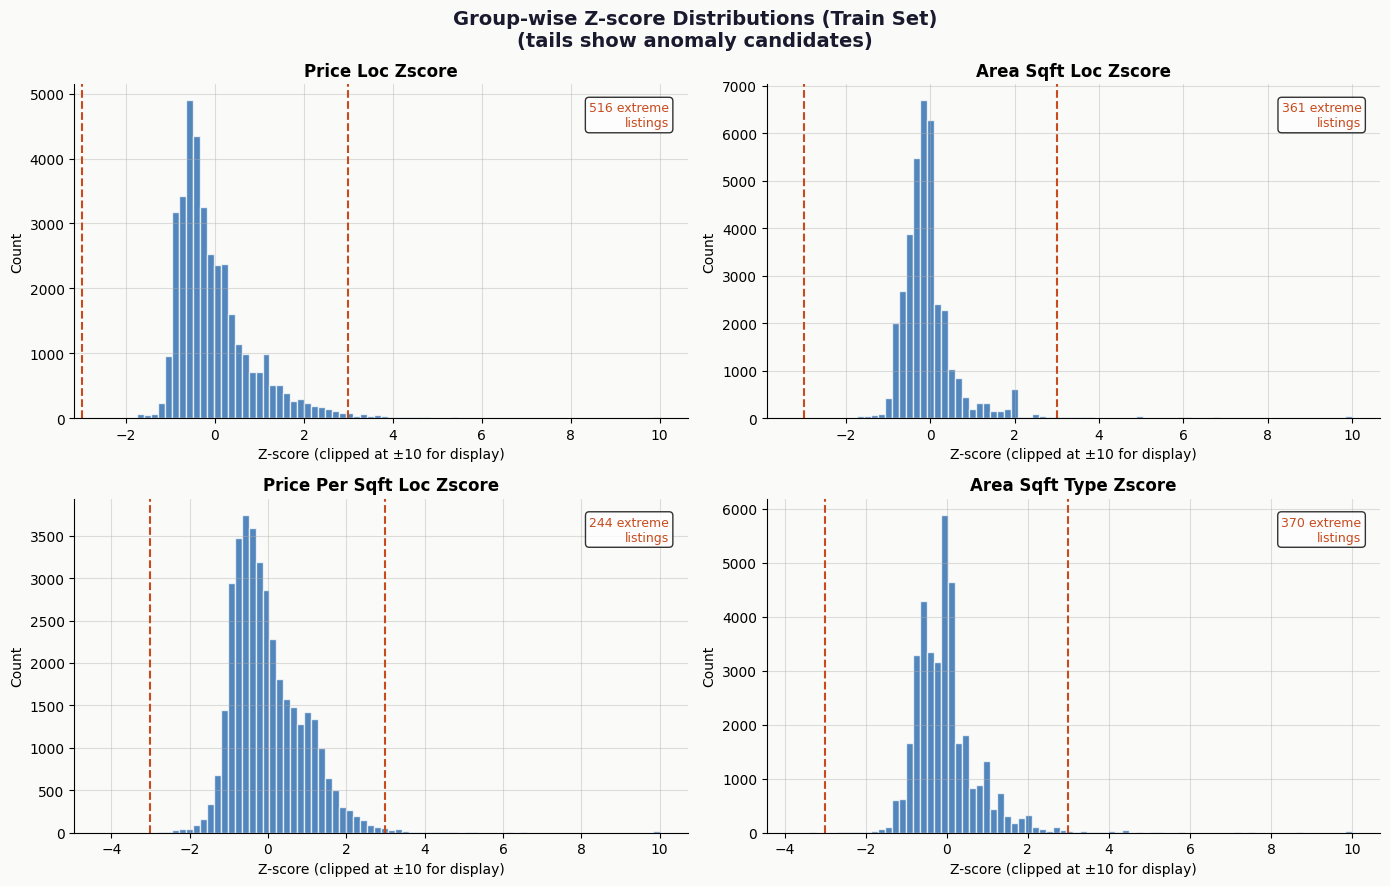

In [22]:
# Visualise z-score distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Group-wise Z-score Distributions (Train Set)\n(tails show anomaly candidates)',
             fontsize=14, fontweight='bold', color='#1a1a2e')

for ax, col in zip(axes.flatten(), zscore_cols):
    data = train_df[col].clip(-10, 10)
    ax.hist(data, bins=80, color=BLUE, alpha=0.75, edgecolor='white')
    ax.axvline(-3, color=ACCENT, linestyle='--', linewidth=1.5, label='z = ±3 threshold')
    ax.axvline(+3, color=ACCENT, linestyle='--', linewidth=1.5)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Z-score (clipped at ±10 for display)')
    ax.set_ylabel('Count')
    extreme = (train_df[col].abs() > 3).sum()
    ax.text(0.97, 0.95, f'{extreme:,} extreme\nlistings',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=ACCENT,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('reports/figures/fe_zscore_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


<h3 style="font-family: 'Times New Roman'; color:red;"><b>7. IQR Deviation Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Add the area_sqft IQR deviation, completing the IQR deviation feature set (price, price-per-sqft, and area). A listing with IQR deviation > 5 is well outside the normal range for its location.</b></i></p>

<hr>

In [23]:
area_iqr_stats = compute_location_stats(train_df, price_col='area_sqft', loc_col='location')
area_iqr_stats.columns = [c.replace('loc_', 'area_loc_') for c in area_iqr_stats.columns]

In [24]:
def apply_area_iqr_deviation(frame, stats):
    d = frame.copy()
    global_med = stats['area_loc_median'].mean()
    global_iqr = stats['area_loc_iqr'].mean()
    d['_a_med'] = d['location'].map(stats['area_loc_median']).fillna(global_med)
    d['_a_iqr'] = d['location'].map(stats['area_loc_iqr']).fillna(global_iqr).replace(0, global_iqr)
    d['area_iqr_deviation'] = (d['area_sqft'] - d['_a_med']) / d['_a_iqr']
    d = d.drop(columns=['_a_med','_a_iqr'])
    return d

In [25]:
train_df = apply_area_iqr_deviation(train_df, area_iqr_stats)
test_df  = apply_area_iqr_deviation(test_df,  area_iqr_stats)

In [26]:
print("IQR deviation features:")
iqr_cols = ['price_iqr_deviation', 'ppsqft_iqr_deviation', 'area_iqr_deviation']
for col in iqr_cols:
    q1  = train_df[col].quantile(0.25)
    med = train_df[col].median()
    q3  = train_df[col].quantile(0.75)
    mx  = train_df[col].max()
    print(f"  {col:<28} Q1={q1:6.2f}  Med={med:6.2f}  Q3={q3:6.2f}  Max={mx:8.2f}")

IQR deviation features:
  price_iqr_deviation          Q1= -0.35  Med=  0.00  Q3=  0.59  Max=  160.67
  ppsqft_iqr_deviation         Q1= -0.39  Med=  0.00  Q3=  0.60  Max=   43.80
  area_iqr_deviation           Q1= -0.43  Med=  0.00  Q3=  0.53  Max=  384.00


In [27]:
print("Listings with |price_iqr_deviation| > 5  :", (train_df['price_iqr_deviation'].abs()>5).sum())
print("Listings with |price_iqr_deviation| > 10 :", (train_df['price_iqr_deviation'].abs()>10).sum())

Listings with |price_iqr_deviation| > 5  : 384
Listings with |price_iqr_deviation| > 10 : 70


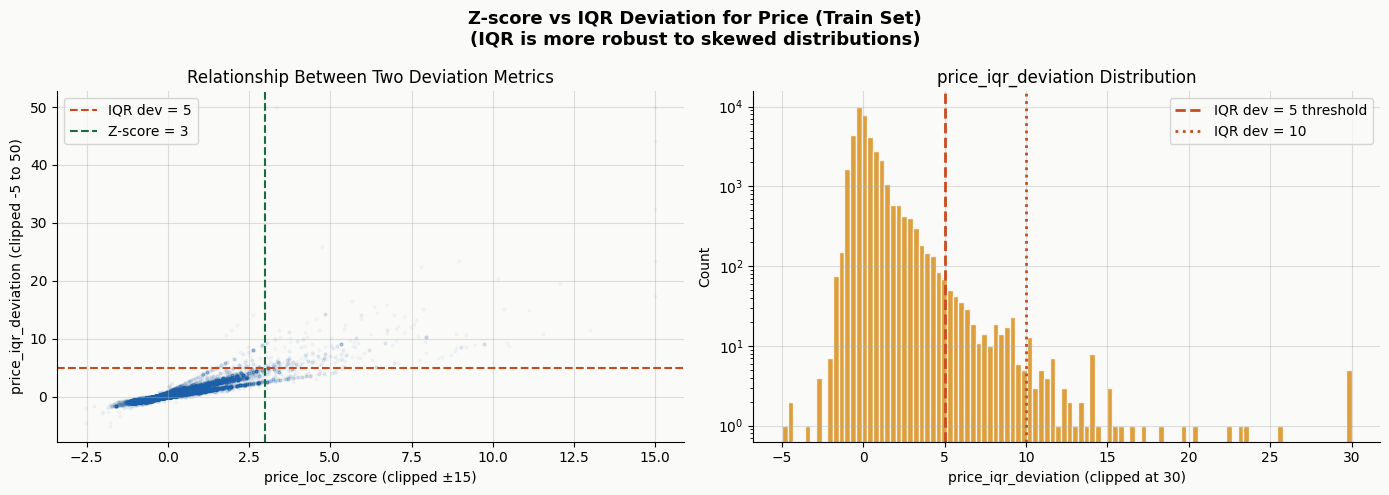

In [28]:
# Compare Z-score vs IQR deviation for same listings it Shows why IQR is better for skewed price data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Z-score vs IQR Deviation for Price (Train Set)\n'
             '(IQR is more robust to skewed distributions)',
             fontsize=13, fontweight='bold')

axes[0].scatter(train_df['price_loc_zscore'].clip(-5,15),
                train_df['price_iqr_deviation'].clip(-5,50),
                alpha=0.03, s=4, color=BLUE)
axes[0].axhline(5,  color=ACCENT, linestyle='--', linewidth=1.5, label='IQR dev = 5')
axes[0].axvline(3,  color=GREEN,  linestyle='--', linewidth=1.5, label='Z-score = 3')
axes[0].set_xlabel('price_loc_zscore (clipped ±15)')
axes[0].set_ylabel('price_iqr_deviation (clipped -5 to 50)')
axes[0].set_title('Relationship Between Two Deviation Metrics')
axes[0].legend()

axes[1].hist(train_df['price_iqr_deviation'].clip(-5, 30), bins=100,
             color=AMBER, alpha=0.8, edgecolor='white')
axes[1].axvline(5,  color=ACCENT, linestyle='--', linewidth=2, label='IQR dev = 5 threshold')
axes[1].axvline(10, color=ACCENT, linestyle=':',  linewidth=2, label='IQR dev = 10')
axes[1].set_xlabel('price_iqr_deviation (clipped at 30)')
axes[1].set_ylabel('Count')
axes[1].set_title('price_iqr_deviation Distribution')
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig('reports/figures/fe_iqr_deviation.png', dpi=150, bbox_inches='tight')
plt.show()


<h3 style="font-family: 'Times New Roman'; color:red;"><b>8. Price Ratio & Consistency Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Compare each listing's price to the median price for the same location and bedroom count. Listings below 50% or above 200% of that expected price are flagged as potentially suspicious (bait listings or price inflation).</b></i></p>
<hr>    

In [29]:
loc_bed_median_train = (
    train_df.groupby(['location', 'bedrooms'])['price'].median().reset_index().rename(columns={'price': '_expected_price'})
)

In [30]:
global_median_price = train_df['price'].median()

In [31]:
def apply_price_ratio_features(frame, loc_bed_stats, global_med):
    d = frame.copy()
    original_index = d.index
    d = d.merge(loc_bed_stats, on=['location', 'bedrooms'], how='left')
    d.index = original_index
    d['_expected_price'] = d['_expected_price'].fillna(global_med)
    d['price_vs_expected_ratio'] = (d['price'] / (d['_expected_price'] + 1e-8)).clip(upper=50)
    d['price_below_50pct_expected']  = (d['price_vs_expected_ratio'] < 0.50).astype(int)
    d['price_above_200pct_expected'] = (d['price_vs_expected_ratio'] > 2.00).astype(int)
    d = d.drop(columns=['_expected_price'])
    return d


In [32]:
train_df = apply_price_ratio_features(train_df, loc_bed_median_train, global_median_price)
test_df  = apply_price_ratio_features(test_df,  loc_bed_median_train, global_median_price)

In [33]:
print(f"price < 50%  of expected (train): {train_df['price_below_50pct_expected'].sum():,} listings")
print(f"price > 200% of expected (train): {train_df['price_above_200pct_expected'].sum():,} listings")


price < 50%  of expected (train): 2,745 listings
price > 200% of expected (train): 2,554 listings


In [34]:
# Location price consistency ( how variable are prices within each area)
cv_by_loc_train = (
    train_df.groupby('location')['price']
    .agg(lambda x: x.std() / (x.mean() + 1e-8))
    .reset_index()
    .rename(columns={'price': 'location_price_cv'})
)

global_cv = cv_by_loc_train['location_price_cv'].mean()

In [35]:
train_df['location_price_cv'] = train_df['location'].map(cv_by_loc_train.set_index('location')['location_price_cv']).fillna(global_cv)
test_df['location_price_cv']  = test_df['location'].map(cv_by_loc_train.set_index('location')['location_price_cv']).fillna(global_cv)

In [36]:
train_df['high_cv_location'] = (train_df['location_price_cv'] > 1.5).astype(int)
test_df['high_cv_location']  = (test_df['location_price_cv']  > 1.5).astype(int)

In [37]:
print(f'Locations with very inconsistent prices (CV > 1.5): 'f'{(cv_by_loc_train["location_price_cv"]>1.5).sum()}')
print(cv_by_loc_train[cv_by_loc_train['location_price_cv']>1.5].sort_values('location_price_cv', ascending=False).to_string(index=False))

Locations with very inconsistent prices (CV > 1.5): 8
          location  location_price_cv
       Kemari Town           2.582769
       Hassan Goth           2.446559
        Tariq Road           2.052114
  National Highway           2.032614
   Shahra-e-Faisal           1.661963
      Naval Colony           1.648204
      KDA Scheme 1           1.593758
Muslimabad Society           1.519490


<h3 style="font-family: 'Times New Roman'; color:red;"><b>9. Bath-to-Bedroom Ratio and Extreme Flag</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Unusual bath-to-bedroom ratios indicate data errors or fraud.A residential property with 12 baths and 4 bedrooms is physically suspicious.
</b></i></p>
<hr>    

In [38]:
# Flag extreme ratios (only for valid bedroom counts)

def add_bath_bed_features(frame: pd.DataFrame) -> pd.DataFrame:
    d = frame.copy()
    d['bath_bed_ratio']  = d['baths'] / (d['bedrooms'] + 1e-8)
    # Zameen.com Karachi data bounds: max bedrooms = 11, min baths = 1
    d['bath_bed_extreme'] = ((d['bath_bed_ratio'] > 3.0) | (d['baths'] == 0)).astype(int)
    d['area_per_bedroom'] = d['area_sqft'] / (d['bedrooms'] + 1)
    return d

In [39]:
train_df = add_bath_bed_features(train_df)
test_df  = add_bath_bed_features(test_df)

In [40]:
print(f"bath_bed_extreme = 1 : {train_df['bath_bed_extreme'].sum():,} ({train_df['bath_bed_extreme'].mean()*100:.1f}%)")
print(f"bath_bed_ratio median: {train_df['bath_bed_ratio'].median():.2f}")

bath_bed_extreme = 1 : 8 (0.0%)
bath_bed_ratio median: 1.00


<h3 style="font-family: 'Times New Roman'; color:red;"><b>10. Market Tier Assignment</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Group locations into Elite, Upper Middle, Middle Class, and Affordable tiers based on median price per sqft, so the model can judge a price as normal or suspicious relative to its local market tier.</b></i></p>
<hr>    


In [41]:
# Compute median price_per_sqft per location
location_stats_train = (
    train_df.groupby('location')
    .agg(
        median_ppsqft  = ('price_per_sqft', 'median'),
        mean_ppsqft    = ('price_per_sqft', 'mean'),
        listing_count  = ('price',          'count'),
        median_price   = ('price',          'median'),
        median_area    = ('area_sqft',       'median'),
    )
    .reset_index()
    .sort_values('median_ppsqft', ascending=False)
)
print(f"Location stats for market tier computed from {len(location_stats_train)} train locations.")


Location stats for market tier computed from 192 train locations.


In [42]:
#Assign tier by percentile cut of median_ppsqft
p25 = location_stats_train['median_ppsqft'].quantile(0.25)
p50 = location_stats_train['median_ppsqft'].quantile(0.50)
p75 = location_stats_train['median_ppsqft'].quantile(0.75)

def assign_tier_derived(ppsqft):
    if   ppsqft >= p75:
        return 'Elite'
    elif ppsqft >= p50:
        return 'Upper Middle'
    elif ppsqft >= p25:
        return 'Middle Class'
    else:
        return 'Affordable'

location_stats_train['market_tier_derived'] = location_stats_train['median_ppsqft'].apply(assign_tier_derived)

In [43]:
# Build lookup maps from train stats
tier_map          = location_stats_train.set_index('location')['market_tier_derived']
listing_count_map = location_stats_train.set_index('location')['listing_count']
median_ppsqft_map = location_stats_train.set_index('location')['median_ppsqft']

In [44]:
# Map to train and test; unseen locations default to 'Middle Class'
train_df['market_tier_derived']     = train_df['location'].map(tier_map).fillna('Middle Class')
test_df['market_tier_derived']      = test_df['location'].map(tier_map).fillna('Middle Class')
train_df['location_listing_count']  = train_df['location'].map(listing_count_map).fillna(0)
test_df['location_listing_count']   = test_df['location'].map(listing_count_map).fillna(0)
train_df['location_median_ppsqft']  = train_df['location'].map(median_ppsqft_map).fillna(median_ppsqft_map.mean())
test_df['location_median_ppsqft']   = test_df['location'].map(median_ppsqft_map).fillna(median_ppsqft_map.mean())


In [45]:
# Save tier map for production
joblib.dump({'tier_map': tier_map, 'p25': p25, 'p50': p50, 'p75': p75}, 'models/artifacts/market_tier_map.pkl')

['models/artifacts/market_tier_map.pkl']

In [46]:
print(f"Tier cut-points (PKR/sqft):")
print(f"  Elite        : >= {p75:,.0f}")
print(f"  Upper Middle : >= {p50:,.0f}")
print(f"  Middle Class : >= {p25:,.0f}")
print(f"  Affordable   : <  {p25:,.0f}")
print()
print("Tier distribution (train):")
print(train_df['market_tier_derived'].value_counts())
print()
print("Tier distribution (test):")
print(test_df['market_tier_derived'].value_counts())

Tier cut-points (PKR/sqft):
  Elite        : >= 9,716
  Upper Middle : >= 6,645
  Middle Class : >= 5,089
  Affordable   : <  5,089

Tier distribution (train):
market_tier_derived
Middle Class    16257
Elite            8537
Upper Middle     8270
Affordable       4269
Name: count, dtype: int64

Tier distribution (test):
market_tier_derived
Middle Class    4005
Elite           2231
Upper Middle    2030
Affordable      1068
Name: count, dtype: int64


<h3 style="font-family: 'Times New Roman'; color:red;"><b>11. Weekly Volume Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Quantify how active each location is week-by-week. A spike in volume
signals coordinated ghost posting or market manipulation.<br>
</b></i></p>
<hr>

In [47]:
 # listings_per_week_in_area — row-level count within train or test independently
print('listings_per_week_in_area loaded from NB01 (computed on full dataset)')
print(f'  Train range: {train_df["listings_per_week_in_area"].min()} – '
      f'{train_df["listings_per_week_in_area"].max()}')
print(f'  Test  range: {test_df["listings_per_week_in_area"].min()} – '
      f'{test_df["listings_per_week_in_area"].max()}')


listings_per_week_in_area loaded from NB01 (computed on full dataset)
  Train range: 1 – 1874
  Test  range: 1 – 1874


In [48]:
# Peak and average weekly volume per location — TRAIN ONLY
wk_stats_train = (train_df.groupby(['location', 'year_week']).size().reset_index(name='week_count'))
peak_stats_train = wk_stats_train.groupby('location').agg(
    peak_weekly_count  = ('week_count', 'max'),
    avg_weekly_count   = ('week_count', 'mean'),
    total_weeks_active = ('week_count', 'count'),
).reset_index()


In [49]:
peak_map  = peak_stats_train.set_index('location')['peak_weekly_count']
avg_map   = peak_stats_train.set_index('location')['avg_weekly_count']
weeks_map = peak_stats_train.set_index('location')['total_weeks_active']

In [50]:
global_peak_weekly  = float(peak_map.mean())
global_avg_weekly   = float(avg_map.mean())
global_weeks_active = float(weeks_map.mean())

joblib.dump({
    'peak_map':           peak_map.to_dict(),
    'avg_map':            avg_map.to_dict(),
    'weeks_map':          weeks_map.to_dict(),
    'global_peak_weekly': global_peak_weekly,
    'global_avg_weekly':  global_avg_weekly,
    'global_weeks_active':global_weeks_active,
}, 'models/artifacts/volume_stats_train.pkl')

print(f"Saved volume_stats_train.pkl — {len(peak_map)} locations")
print(f"  Global avg weekly volume : {global_avg_weekly:.1f}")
print(f"  Global peak weekly count : {global_peak_weekly:.1f}")

Saved volume_stats_train.pkl — 192 locations
  Global avg weekly volume : 8.3
  Global peak weekly count : 35.7


In [51]:
global_peak  = peak_map.mean()
global_avg   = avg_map.mean()
global_weeks = weeks_map.mean()

In [52]:
# How active is This week compared to the area's average
for frame in [train_df, test_df]:
    frame['peak_weekly_count']   = frame['location'].map(peak_map).fillna(global_peak)
    frame['avg_weekly_count']    = frame['location'].map(avg_map).fillna(global_avg)
    frame['total_weeks_active']  = frame['location'].map(weeks_map).fillna(global_weeks)
    frame['weekly_volume_ratio'] = (frame['listings_per_week_in_area'] / (frame['avg_weekly_count'] + 1e-8))


In [53]:
print("Temporal volume features (train stats only):")
print(f"  max listings_per_week_in_area (train): {train_df['listings_per_week_in_area'].max():,}")
print(f"  max weekly_volume_ratio (train)       : {train_df['weekly_volume_ratio'].max():.1f}×")
print(f"  spike weeks ratio > 3 (train)         : {(train_df['weekly_volume_ratio'] > 3).sum():,} listings")


Temporal volume features (train stats only):
  max listings_per_week_in_area (train): 1,874
  max weekly_volume_ratio (train)       : 13.2×
  spike weeks ratio > 3 (train)         : 19,052 listings


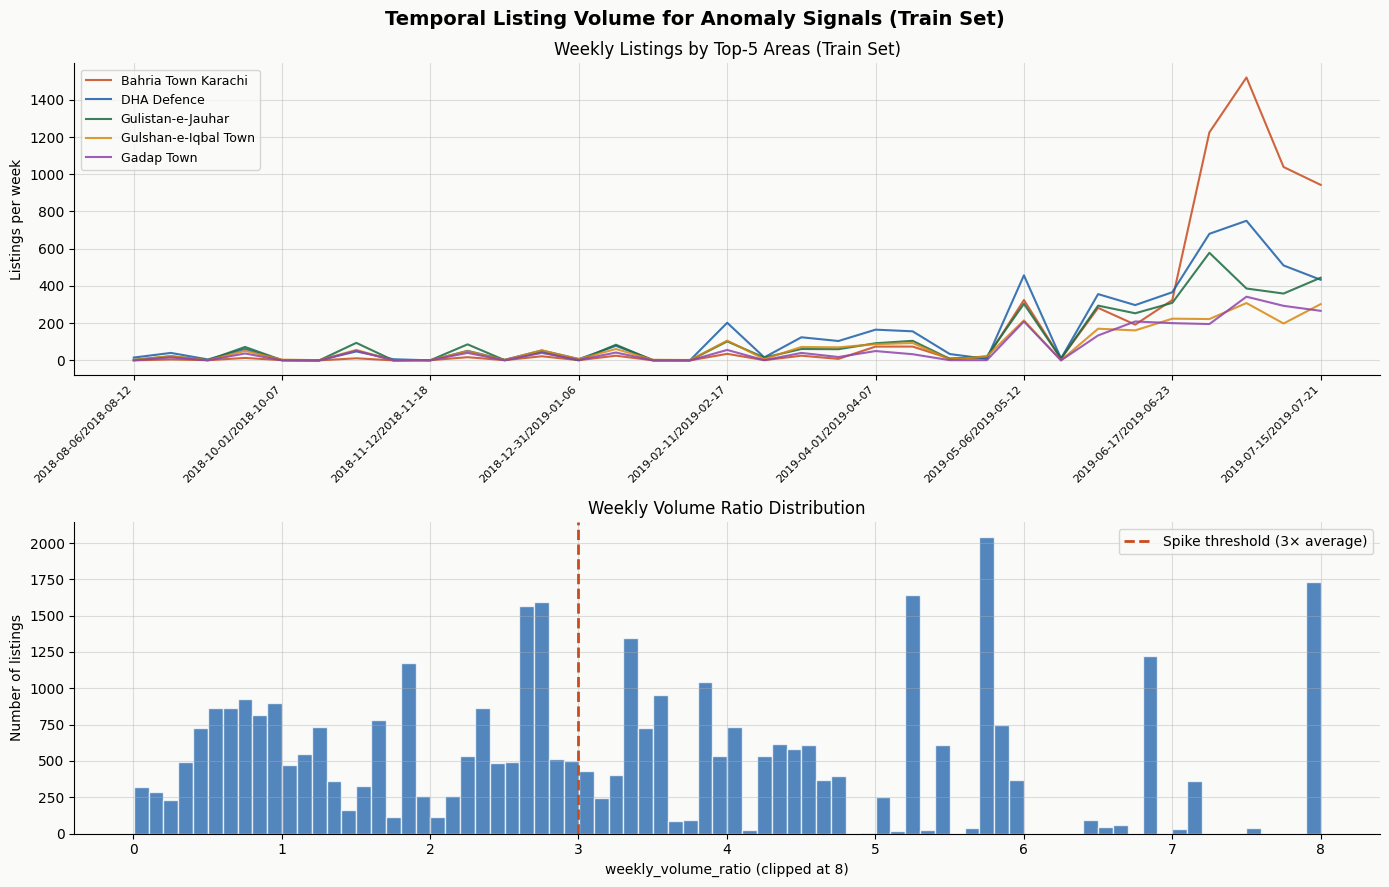

In [54]:
# Visualise temporal spikes
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Temporal Listing Volume for Anomaly Signals (Train Set)', fontsize=14, fontweight='bold')

top5 = train_df['location'].value_counts().head(5).index.tolist()
wk_top5 = (wk_stats_train[wk_stats_train['location'].isin(top5)]
           .pivot(index='year_week', columns='location', values='week_count')
           .fillna(0)
           .sort_index())

colors_top5 = [ACCENT, BLUE, GREEN, AMBER, '#8e44ad']
for i, loc in enumerate(top5):
    if loc in wk_top5.columns:
        axes[0].plot(range(len(wk_top5)), wk_top5[loc],
                     label=loc[:20], color=colors_top5[i % 5],
                     linewidth=1.5, alpha=0.85)

axes[0].set_title('Weekly Listings by Top-5 Areas (Train Set)')
axes[0].set_ylabel('Listings per week')
axes[0].set_xticks(range(0, len(wk_top5), 4))
axes[0].set_xticklabels(wk_top5.index[::4], rotation=45, ha='right', fontsize=8)
axes[0].legend(fontsize=9)

axes[1].hist(train_df['weekly_volume_ratio'].clip(0, 8), bins=80,
             color=BLUE, alpha=0.75, edgecolor='white')
axes[1].axvline(3, color=ACCENT, linestyle='--', linewidth=2,
                label='Spike threshold (3× average)')
axes[1].set_xlabel('weekly_volume_ratio (clipped at 8)')
axes[1].set_ylabel('Number of listings')
axes[1].set_title('Weekly Volume Ratio Distribution')
axes[1].legend()
plt.tight_layout()
plt.savefig('reports/figures/fe_temporal_features.png', dpi=150, bbox_inches='tight')
plt.show()


<h3 style="font-family: 'Times New Roman'; color:red;"><b>12. Relisting Intensity Features</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Quantify how aggressively a listing has been re-posted.
Ghost listings are repeatedly posted to stay at the top of search results.
Log transforming the relisting count compresses the extreme tail
(some listings reposted 200+ times) into a model-friendly range.
</b></i></p>
<hr>    

In [55]:
assert 'relisting_count' in train_df.columns, \
    "relisting_count missing — check NB01 saves it to all_listings_with_flags.csv"
assert 'relisting_count' in test_df.columns

print('relisting_count — using NB01 full-dataset values (no per-split recompute)')
print(f'  Train ghost candidates (≥5): {(train_df["relisting_count"] >= 5).sum():,}')
print(f'  Test  ghost candidates (≥5): {(test_df["relisting_count"] >= 5).sum():,}')


relisting_count — using NB01 full-dataset values (no per-split recompute)
  Train ghost candidates (≥5): 14,356
  Test  ghost candidates (≥5): 3,547


In [56]:
def add_relisting_features(frame: pd.DataFrame) -> pd.DataFrame:
    d = frame.copy()
    d['relisting_intensity'] = np.log1p(d['relisting_count'])
    d['is_multi_relisted']   = (d['relisting_count'] >= 10).astype(int)
    return d

In [57]:
train_df = add_relisting_features(train_df)
test_df  = add_relisting_features(test_df)

print(f'\nrelisting_intensity (train): mean={train_df["relisting_intensity"].mean():.2f}, '
      f'max={train_df["relisting_intensity"].max():.2f}')


relisting_intensity (train): mean=1.66, max=5.39


<h3 style="font-family: 'Times New Roman'; color:red;"><b>13. Heuristic Anomaly Score</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Combine all anomaly signals into a single weighted composite score, higher meaning more suspicious. This is not a model, it is a rule-based score used for EDA and as an evaluation proxy since there's no verified ground truth.</b></i></p>
<hr>   

In [58]:
# Heuristic anomaly score only for EDA
def compute_heuristic_score(frame: pd.DataFrame) -> pd.Series:
    score = (
        frame['price_loc_zscore'].abs()                    * 0.30 +
        frame['ppsqft_iqr_deviation'].abs().clip(upper=10) * 0.25 +
        frame['relisting_intensity']                        * 0.20 +
        frame['ghost_listing_flag']                         * 2.00 +
        frame['geo_anomaly']                                * 5.00 +
        frame['bath_bed_extreme']                           * 3.00 +
        frame['price_too_low_flag']                         * 4.00 +
        frame['price_very_high_flag']                       * 4.00
    ).fillna(0)
    return score



In [59]:
train_df['heuristic_anomaly_score'] = compute_heuristic_score(train_df)
test_df['heuristic_anomaly_score']  = compute_heuristic_score(test_df)

In [60]:
print("Heuristic anomaly score distribution (train):")
print(train_df['heuristic_anomaly_score'].describe().round(3).to_string())
print()
top5_suspicious = train_df.nlargest(5, 'heuristic_anomaly_score')[ ['location','property_type','price','bedrooms','baths',
     'relisting_count','geo_anomaly','heuristic_anomaly_score']]
print('\nTop 5 most suspicious listings (train):')
print(top5_suspicious.to_string(index=False))

Heuristic anomaly score distribution (train):
count    37333.000
mean         0.888
std          0.765
min          0.139
25%          0.435
50%          0.637
75%          0.972
max         12.895


Top 5 most suspicious listings (train):
            location property_type      price  bedrooms  baths  relisting_count  geo_anomaly  heuristic_anomaly_score
 Bahria Town Karachi         House  250000000         3      3                1            0                12.895467
             Clifton         House 1000000000        11     10                1            0                11.116577
Gulshan-e-Iqbal Town         House  540000000         6      6                1            0                 9.902073
         DHA Defence         House  690000000         6      6                1            0                 9.128701
           Nazimabad         House  350000000         6      6                1            0                 8.251699


<h3 style="font-family: 'Times New Roman'; color:red;"><b>14. Categorical Encoding</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Convert text columns into numbers so ML models can use them.
</b></i></p>
<hr>

In [61]:
def frequency_encode(train_series: pd.Series, test_series: pd.Series):
    """Encode location by its frequency in training data."""
    freq_map = train_series.value_counts().to_dict()
    train_enc = train_series.map(freq_map).fillna(0).astype(int)
    test_enc  = test_series.map(freq_map).fillna(0).astype(int)  # unseen = 0
    return train_enc, test_enc, freq_map

In [62]:
train_df['location_enc'], test_df['location_enc'], loc_freq_map = frequency_encode(train_df['location'], test_df['location'])

In [63]:
joblib.dump(loc_freq_map, 'models/artifacts/loc_freq_map.pkl')
print(f'Frequency encoding applied to {len(loc_freq_map)} locations (train only)')
print(f'  Min freq: {min(loc_freq_map.values())}  Max freq: {max(loc_freq_map.values())}')

Frequency encoding applied to 192 locations (train only)
  Min freq: 1  Max freq: 6197


In [64]:
# One-hot encode property_type and market_tier
ohe_cols = ['property_type', 'market_tier_derived']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.int8)
ohe.fit(train_df[ohe_cols])

OneHotEncoder(dtype=<class 'numpy.int8'>, handle_unknown='ignore',
              sparse_output=False)

In [65]:
ohe_feature_names = ohe.get_feature_names_out(ohe_cols).tolist()

train_ohe = pd.DataFrame(ohe.transform(train_df[ohe_cols]),columns=ohe_feature_names,index=train_df.index,)
test_ohe = pd.DataFrame( ohe.transform(test_df[ohe_cols]), columns=ohe_feature_names, index=test_df.index,)

In [66]:
train_df = pd.concat([train_df, train_ohe], axis=1)
test_df  = pd.concat([test_df,  test_ohe],  axis=1)

joblib.dump(ohe, 'models/artifacts/ohe_encoder.pkl')

['models/artifacts/ohe_encoder.pkl']

In [67]:
print("One-hot encoding complete (fitted on train, applied to both):")
print(f"  OHE columns added ({len(ohe_feature_names)}): {ohe_feature_names}")
print(f"  Train shape after OHE: {train_df.shape}")
print(f"  Test  shape after OHE: {test_df.shape}")


One-hot encoding complete (fitted on train, applied to both):
  OHE columns added (11): ['property_type_Farm House', 'property_type_Flat', 'property_type_House', 'property_type_Lower Portion', 'property_type_Penthouse', 'property_type_Room', 'property_type_Upper Portion', 'market_tier_derived_Affordable', 'market_tier_derived_Elite', 'market_tier_derived_Middle Class', 'market_tier_derived_Upper Middle']
  Train shape after OHE: (37333, 69)
  Test  shape after OHE: (9334, 69)


<h3 style="font-family: 'Times New Roman'; color:red;"><b>15. Feature Correlation Heatmap</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Check for highly correlated features among the core anomaly signals that could cause redundancy. Pairs with correlation above 0.85 are flagged for review.</b></i></p>
<hr>    

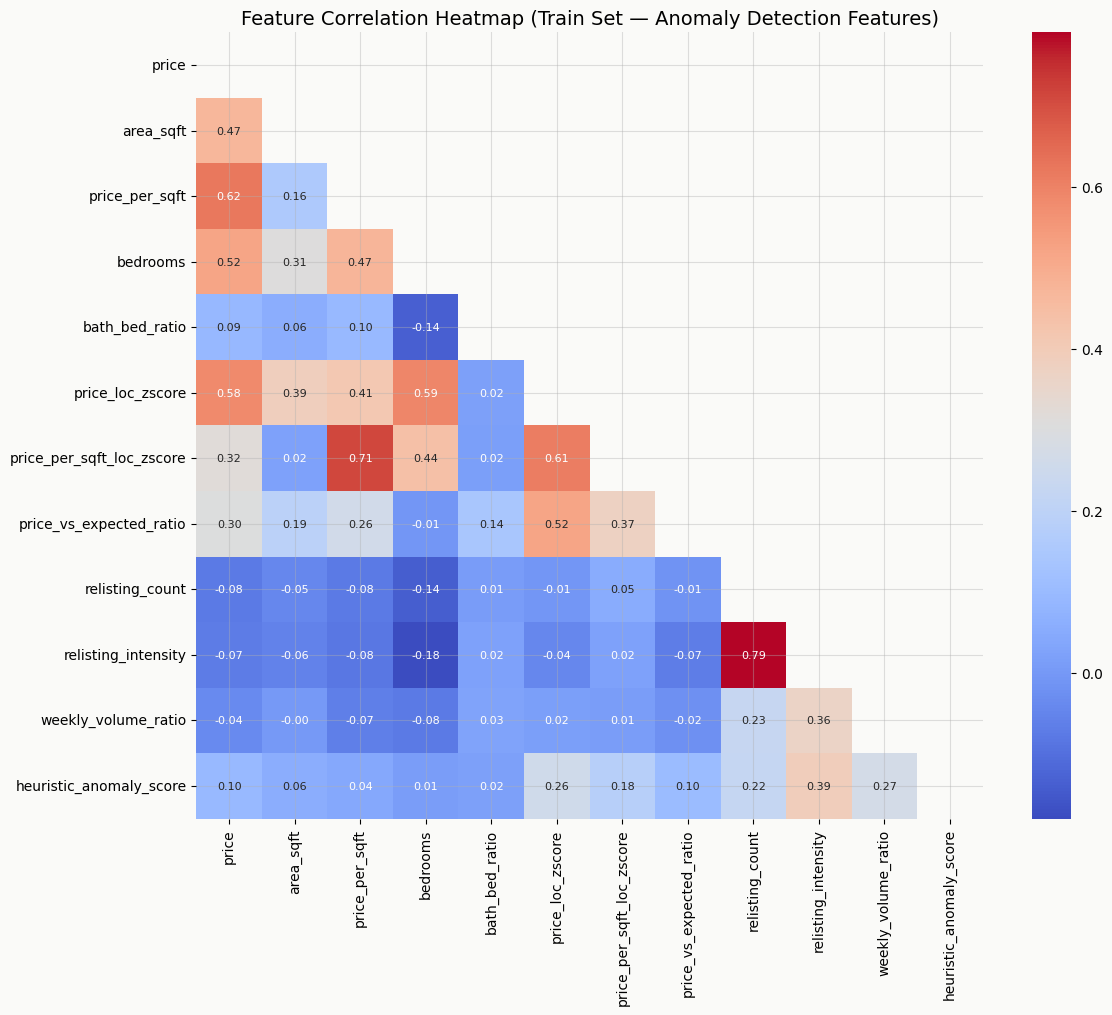

In [68]:
# Correlation heatmap of top features
top_feats = [
    'price', 'area_sqft', 'price_per_sqft',
    'bedrooms', 'bath_bed_ratio',
    'price_loc_zscore', 'price_per_sqft_loc_zscore',
    'price_vs_expected_ratio',
    'relisting_count', 'relisting_intensity',
    'weekly_volume_ratio', 'heuristic_anomaly_score',
]
top_feats = [c for c in top_feats if c in train_df.columns]

corr = train_df[top_feats].corr()

fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            annot_kws={'size':8}, square=True)
ax.set_title('Feature Correlation Heatmap (Train Set — Anomaly Detection Features)', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [69]:

# Flag highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.85:
            high_corr_pairs.append((corr.columns[i], corr.columns[j], round(val, 3)))

if high_corr_pairs:
    print("Highly correlated pairs (|r| > 0.85) — consider dropping one from each pair:")
    for a, b, v in high_corr_pairs:
        print(f"  {a} <-> {b}  (r = {v})")
else:
    print("No feature pairs with |r| > 0.85 — no obvious redundancy.")


No feature pairs with |r| > 0.85 — no obvious redundancy.


<h3 style="font-family: 'Times New Roman'; color:red;"><b>16. Feature Selection</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>
Goal: Select the features that will be passed to the models.Exclude: raw text columns, date columns, identifier columns, intermediate calculation columns.
</b></i></p>
<hr>    

In [70]:
ohe_model_cols = ohe_feature_names
model_feature_cols = [
    # Property raw features
    'price', 'area_sqft', 'price_per_sqft', 'bedrooms', 'baths',
    # Derived property features
    'bath_bed_ratio', 'area_per_bedroom',
    # Z-scores (computed from train only — no leakage)
    'price_loc_zscore', 'area_sqft_loc_zscore',
    'price_per_sqft_loc_zscore', 'area_sqft_type_zscore',
    # IQR deviations (computed from train only)
    'price_iqr_deviation', 'ppsqft_iqr_deviation', 'area_iqr_deviation',
    # Ratio features
    'price_vs_expected_ratio', 'location_price_cv',
    # Temporal
    'listing_month', 'listing_quarter', 'listing_dow',
    'listing_week', 'is_weekend',
    'listings_per_week_in_area', 'peak_weekly_count', 'weekly_volume_ratio',
    # Relisting (the REAL signal for ghost listings)
    'relisting_count', 'relisting_intensity', 'is_multi_relisted',
    # FE flags (derived from upstream data, NOT label components)
    'bath_bed_extreme', 'high_cv_location',
    'price_below_50pct_expected', 'price_above_200pct_expected',
    # Location encoding
    'location_enc',
]


In [71]:
label_component_cols = [
    'price_too_low_flag',    # component of is_suspicious
    'price_very_high_flag',  # component of is_suspicious
    'ghost_listing_flag',    # component of is_suspicious
    'lat_anomaly',           # component of geo_anomaly → is_suspicious
    'lon_anomaly',           # component of geo_anomaly → is_suspicious
    'geo_anomaly',           # component of is_suspicious
    'is_suspicious',         # the label itself
    'heuristic_anomaly_score', # weighted sum of flag columns
]

before_count = len(model_feature_cols)
model_feature_cols = [c for c in model_feature_cols if c not in label_component_cols]

print(f'Label-component columns removed: {before_count - len(model_feature_cols)}')
print(f'Features remaining             : {len(model_feature_cols)}')
print()
print('The fraud signal is still captured through:')
print('  price_iqr_deviation     — replaces price_too_low_flag / price_very_high_flag')
print('  ppsqft_iqr_deviation    — replaces price flags with a continuous signal')
print('  relisting_intensity     — replaces ghost_listing_flag with a continuous signal')
print('  area_sqft_loc_zscore    — captures area outliers without the flag')

Label-component columns removed: 0
Features remaining             : 32

The fraud signal is still captured through:
  price_iqr_deviation     — replaces price_too_low_flag / price_very_high_flag
  ppsqft_iqr_deviation    — replaces price flags with a continuous signal
  relisting_intensity     — replaces ghost_listing_flag with a continuous signal
  area_sqft_loc_zscore    — captures area outliers without the flag


In [72]:

# Add OHE columns
model_feature_cols += ohe_model_cols
# Save feature list for the model notebook
joblib.dump(model_feature_cols, 'models/artifacts/model_feature_cols.pkl')

print(f"Total model features : {len(model_feature_cols)}")
print()
for c in model_feature_cols:
    print(f"  {c}")



Total model features : 43

  price
  area_sqft
  price_per_sqft
  bedrooms
  baths
  bath_bed_ratio
  area_per_bedroom
  price_loc_zscore
  area_sqft_loc_zscore
  price_per_sqft_loc_zscore
  area_sqft_type_zscore
  price_iqr_deviation
  ppsqft_iqr_deviation
  area_iqr_deviation
  price_vs_expected_ratio
  location_price_cv
  listing_month
  listing_quarter
  listing_dow
  listing_week
  is_weekend
  listings_per_week_in_area
  peak_weekly_count
  weekly_volume_ratio
  relisting_count
  relisting_intensity
  is_multi_relisted
  bath_bed_extreme
  high_cv_location
  price_below_50pct_expected
  price_above_200pct_expected
  location_enc
  property_type_Farm House
  property_type_Flat
  property_type_House
  property_type_Lower Portion
  property_type_Penthouse
  property_type_Room
  property_type_Upper Portion
  market_tier_derived_Affordable
  market_tier_derived_Elite
  market_tier_derived_Middle Class
  market_tier_derived_Upper Middle


In [73]:
# Build X matrices (features only) and y vectors (labels)
X_train = train_df[model_feature_cols].copy()
X_test  = test_df[model_feature_cols].copy()
y_train = train_df['is_suspicious'].copy()
y_test  = test_df['is_suspicious'].copy()

In [74]:
# NaN check
nan_train = X_train.isnull().sum().sum()
nan_test  = X_test.isnull().sum().sum()

if nan_train > 0:
    print(f"WARNING: {nan_train} NaN values in X_train — filling with 0.")
    X_train = X_train.fillna(0)
if nan_test > 0:
    print(f"WARNING: {nan_test} NaN values in X_test — filling with 0.")
    X_test = X_test.fillna(0)

if nan_train == 0 and nan_test == 0:
    print("No NaN values found in feature matrices.")

No NaN values found in feature matrices.


In [75]:
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"\nLabel distribution (train): clean={( y_train==0).sum():,}  suspicious={(y_train==1).sum():,}  rate={y_train.mean():.2%}")
print(f"Label distribution (test) : clean={(  y_test==0).sum():,}  suspicious={(y_test==1).sum():,}  rate={y_test.mean():.2%}")



X_train shape : (37333, 43)
X_test  shape : (9334, 43)

Label distribution (train): clean=33,763  suspicious=3,570  rate=9.56%
Label distribution (test) : clean=8,441  suspicious=893  rate=9.57%


<li><b>Soft leakage caveat:</b> Even though the four literal flag columns are excluded,
<code>is_suspicious</code> is a deterministic threshold function of <code>price</code>
and <code>relisting_count</code> — both of which remain in the feature set.
A tree model can reconstruct most of the heuristic's logic with a handful of
splits on those columns. The PR-AUC of ~0.12–0.13 seen when evaluating
against the heuristic label (NB05 Section 8) partly reflects this re-derivation,
not independent fraud signal discovery.</li>

<h3 style="font-family: 'Times New Roman'; color: red;"><b>17. Feature Clipping</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Cap extreme values in deviation features before scaling. This stops a single extreme outlier from stretching the entire scale and making every other listing look the same.</b></i></p>
<hr>

In [76]:
# Feature Clipping Before Scaling

# Data-driven clip bounds from TRAIN only
deviation_cols_to_clip = [
    'price_iqr_deviation',
    'ppsqft_iqr_deviation',
    'area_iqr_deviation',
    'price_vs_expected_ratio',
    'price_loc_zscore',
    'area_sqft_loc_zscore',
]

# Lower bounds are symmetric negatives (outlier anomalies are mostly on the high side)
lower_sentinels = {
    'price_iqr_deviation': -10,
    'ppsqft_iqr_deviation': -10,
    'area_iqr_deviation':-10,
    'price_vs_expected_ratio':0,
    'price_loc_zscore':-5,
    'area_sqft_loc_zscore':-5,
}


In [77]:
clip_limits = {}
print("Data-driven clip bounds (99.9th percentile of train set):")
for col in deviation_cols_to_clip:
    if col in X_train.columns:
        lower = lower_sentinels.get(col, -10)
        upper = float(X_train[col].quantile(0.999))
        clip_limits[col] = (lower, upper)
        print(f"  {col:<30} lower={lower:6.1f}  upper={upper:8.2f}")

Data-driven clip bounds (99.9th percentile of train set):
  price_iqr_deviation            lower= -10.0  upper=   11.97
  ppsqft_iqr_deviation           lower= -10.0  upper=    7.84
  area_iqr_deviation             lower= -10.0  upper=   43.91
  price_vs_expected_ratio        lower=   0.0  upper=    9.34
  price_loc_zscore               lower=  -5.0  upper=    7.89
  area_sqft_loc_zscore           lower=  -5.0  upper=   10.50


In [78]:
print("Applying clip bounds to train and test...")
for col, (lower, upper) in clip_limits.items():
    if col in X_train.columns:
        n_clipped_train = (X_train[col] > upper).sum() + (X_train[col] < lower).sum()
        X_train[col] = X_train[col].clip(lower, upper)
        X_test[col]  = X_test[col].clip(lower, upper)
        if n_clipped_train > 0:
            print(f"  Clipped {n_clipped_train:,} values in {col}")

# Save clip bounds for production
joblib.dump(clip_limits, 'models/artifacts/clip_limits.pkl')
print("\nFeature clipping completed. Bounds saved to clip_limits.pkl")

Applying clip bounds to train and test...
  Clipped 38 values in price_iqr_deviation
  Clipped 37 values in ppsqft_iqr_deviation
  Clipped 38 values in area_iqr_deviation
  Clipped 38 values in price_vs_expected_ratio
  Clipped 38 values in price_loc_zscore
  Clipped 38 values in area_sqft_loc_zscore

Feature clipping completed. Bounds saved to clip_limits.pkl


<h3 style="font-family: 'Times New Roman'; color: red;"><b>18. Feature Scaling</b></h3>
<hr>
<p style="font-family: Arial; font-size:16px; color:black;"><i><b>Goal: Scale all features to the same range. The scaler is fit on training data only, then applied to test data, so no information leaks from test into train.</b></i></p>
<hr>

In [79]:
# RobustScaler for Isolation Forest and LOF
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust  = robust_scaler.transform(X_test)

# StandardScaler for One-Class SVM
standard_scaler = StandardScaler()
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard  = standard_scaler.transform(X_test)

In [80]:
print("Scalers fitted on training data.")
print(f"  RobustScaler -> shape: {X_train_robust.shape}")
print(f"  StandardScaler -> shape: {X_train_standard.shape}")

Scalers fitted on training data.
  RobustScaler -> shape: (37333, 43)
  StandardScaler -> shape: (37333, 43)


In [81]:
# Save scalers to used identically in FastAPI prediction pipeline
joblib.dump(robust_scaler,   f'models/artifacts/scaler_robust_v1.pkl')
joblib.dump(standard_scaler, f'models/artifacts/scaler_standard_v1.pkl')

# Save scaled arrays
np.save(f'models/artifacts/X_train_robust.npy',   X_train_robust)
np.save(f'models/artifacts/X_test_robust.npy',    X_test_robust)
np.save(f'models/artifacts/X_train_standard.npy', X_train_standard)
np.save(f'models/artifacts/X_test_standard.npy',  X_test_standard)

#  Save with names the model notebook expects
X_train.to_csv(f'models/artifacts/X_train.csv', index=True)
X_test.to_csv( f'models/artifacts/X_test.csv',  index=True)
y_train.to_csv(f'models/artifacts/y_train.csv', index=False)
y_test.to_csv(f'models/artifacts/y_test.csv',   index=False)

print("All artifacts saved:")

All artifacts saved:


In [82]:
train_df['split'] = 'train'
test_df['split']  = 'test'
# FIX (index-alignment bug — see chat analysis): ignore_index=True was discarding the
# original pre-split row labels and reassigning a fresh 0..N-1 index in concat order
# (train rows first, then test rows). X_train.csv / X_test.csv keep the ORIGINAL index,
# so NB04's df.loc[X_train_df.index, ...] was silently pulling the wrong rows —
# this is the root cause of every model landing at ROC-AUC ~0.50 in NB05/06.
# Fix: preserve the original index through the concat and save it.
df_full_fe = pd.concat([train_df, test_df])
df_full_fe.to_csv('data/preprocessed/feature_engineered.csv', index=True)

print(f'Saved feature_engineered.csv')
print(f'Shape: {df_full_fe.shape}')
print(f'Columns: {df_full_fe.shape[1]}')
print(f'Index preserved: {df_full_fe.index.is_unique} unique, range {df_full_fe.index.min()}-{df_full_fe.index.max()}')

Saved feature_engineered.csv
Shape: (46667, 70)
Columns: 70
Index preserved: True unique, range 0-46666


<h4 style="font-family: Arial;"><b>Key Observations:</b></h4>
<ul style="font-family: Arial; color: green; font-size:16px;"><i>
<li><b>Why we keep outliers in this notebook:</b> Unlike a standard data science project, we do NOT remove extreme values here. In anomaly detection, the extreme values ARE what we are trying to detect: a property priced far below or above what's typical for its area, or a flat with an implausible number of bathrooms. Removing them would make the model blind to the most obvious fraud signals.</li>
<li><b>Z-score features (4 features):</b> These measure how different each listing's price and area are compared to other listings in the same location. A z-score of +4 means the price is 4 standard deviations above the local average, which is very unusual.</li>
<li><b>IQR deviation features (3 features):</b> A more reliable version of z-score for skewed data like property prices. Property prices are never normally distributed, there are always a few very expensive ones that pull the average up. IQR ignores these extremes when measuring spread, giving a fairer picture of what is normal in each area.</li>
<li><b>Price ratio features (5 features):</b> These compare each listing's price against what a similar property (same location, same number of bedrooms) normally costs. A listing priced at 40% of the expected amount is suspicious, it could be a bait listing designed to attract clicks even though the property does not really exist at that price.</li>
<li><b>Temporal features (8 features):</b> Calendar features like month, week, and day of week plus weekly volume signals. A week where one area posts 3 times its normal volume is a strong ghost listing signal (someone is flooding the market with fake or duplicate posts).</li>
<li><b>Relisting features (3 features):</b> The log-transformed relisting count and a binary flag for listings reposted 10 or more times. These directly capture ghost listing behaviour detected in the cleaning notebook.</li>
<li><b>Train-test split is stratified:</b> We split 80/20 using the is_suspicious label from notebook 01. Stratified means both sets have the same percentage of suspicious listings, so the test set is a fair sample.</li>
<li><b>Scaler fitted on train only:</b> This is critical. If we fit the scaler on all data before splitting, information from the test set leaks into training and our evaluation results are misleading. Always fit on train, then transform test using the same fitted scaler.</li>
</ul>